In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [3]:
df = pd.read_csv('US_honey_dataset_updated.csv')

In [3]:
df.head(5)

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


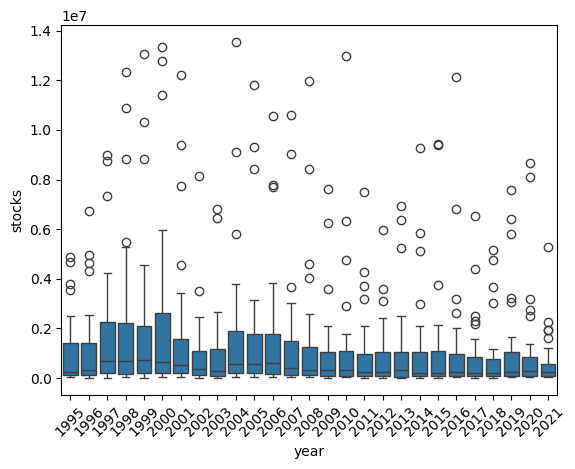

In [ ]:
sns.boxplot(x='year', y='stocks', data=df)
plt.xticks(rotation=45)
plt.show()

In [5]:
arizona = df[df['state'] == 'Arizona']

In [ ]:
arizona['stocks','year']

1        986000
45       307000
89      1024000
132     1485000
175     1548000
218     1322000
261     1142000
304     1197000
348     1123000
392      774000
432      720000
473      839000
514      902000
555      336000
596      562000
637      665000
677      427000
717      253000
757      251000
796      193000
836      306000
876      261000
916       97000
956      109000
996      201000
1036     360000
1076     368000
Name: stocks, dtype: int64

In [18]:
z_score = np.abs(stats.zscore(df['stocks']))

In [22]:
outliers = df[z_score > 3]

In [23]:
cleandata = df[z_score < 3]

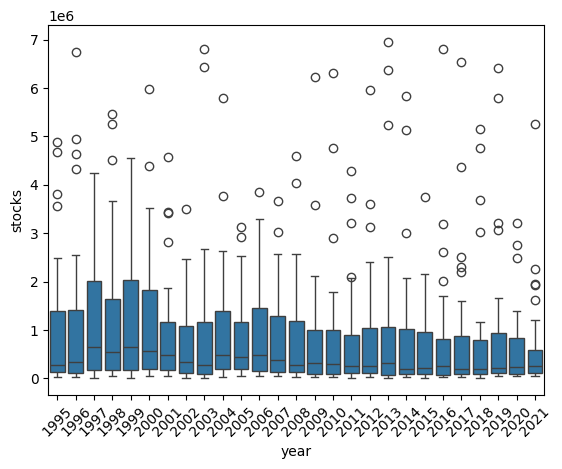

In [24]:
sns.boxplot(x='year', y='stocks', data=cleandata)
plt.xticks(rotation=45)
plt.show()

In [31]:
q1 = df['stocks'].quantile(0.25)
q3 = df['stocks'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [32]:
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")

Lower bound: -1599000.0
Upper bound: 2965000.0


In [33]:
outliers = df[(df['stocks'] < lower) | (df['stocks'] > upper)]

In [34]:
outliers

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
17,17,Michigan,97000,92,8924000,3570000,72.00,6425000,1995
28,28,NorthDakota,220000,108,23760000,3802000,63.00,14969000,1995
34,34,SouthDakota,240000,85,20400000,4896000,65.00,13260000,1995
47,47,California,390000,70,27300000,4641000,84.00,22932000,1996
...,...,...,...,...,...,...,...,...,...
1025,1025,SouthDakota,270000,72,7582000,7582000,1.56,30326000,2019
1055,1055,Montana,110000,81,3208000,3208000,1.61,14345000,2020
1060,1060,NorthDakota,495000,78,8108000,8108000,1.59,61390000,2020
1065,1065,SouthDakota,245000,61,8668000,8668000,1.77,26453000,2020


In [36]:
cleandata = df[(df['stocks'] > lower) & (df['stocks'] < upper)]
cleandata

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
5,5,Florida,230000,86,19780000,1780000,63.00,12461000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


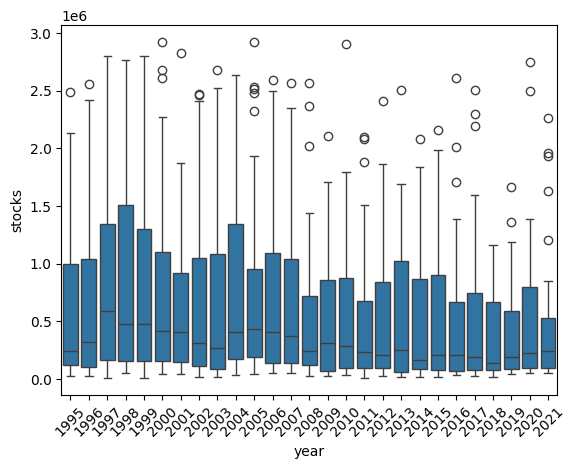

In [37]:
sns.boxplot(x='year', y='stocks', data=cleandata)
plt.xticks(rotation=45)
plt.show()

In [ ]:
cleandata[cleandata['year'] == 1997]

In [50]:
median = np.median(df['stocks'])

In [51]:
mad = np.median(np.abs(df['stocks'] - median))

In [52]:
df['modified'] = 0.6745 * (df['stocks'] - median) / mad

In [53]:
outliers = df[np.abs(df['modified']) > 3.5]

In [54]:
cleandata_modified = df[np.abs(df['modified']) < 3.5]

In [55]:
cleandata_modified

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year,modified
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995,-0.744126
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995,1.340297
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995,1.153177
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995,2.249784
5,5,Florida,230000,86,19780000,1780000,63.00,12461000,1995,3.067887
...,...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021,-0.633160
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021,1.818974
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021,-0.509139
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021,0.826806


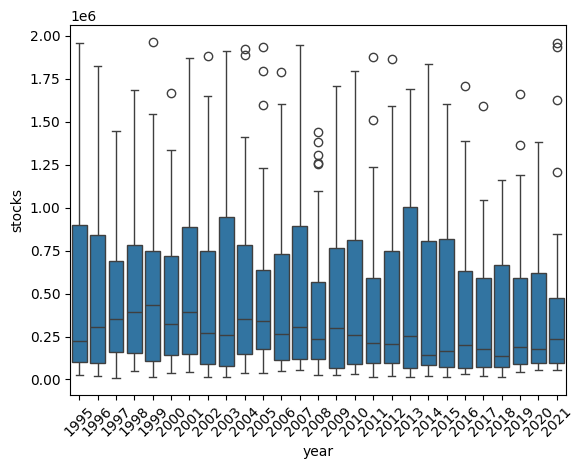

In [56]:
sns.boxplot(x='year', y='stocks', data=cleandata_modified)
plt.xticks(rotation=45)
plt.show()

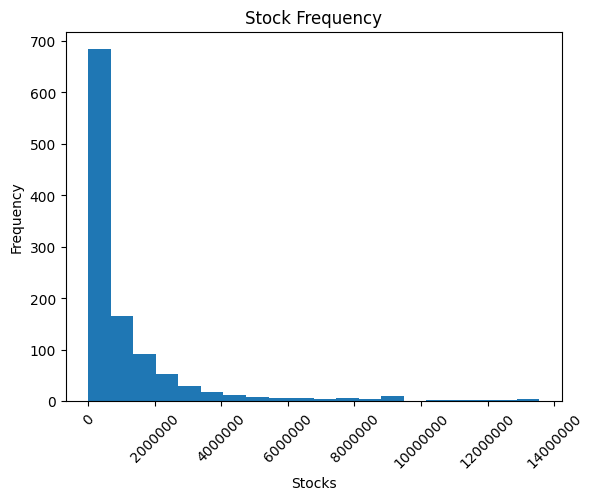

In [69]:
plt.hist(df['stocks'], bins=20)
plt.title('Stock Frequency')
plt.xlabel('Stocks')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain')
plt.show()

In [70]:
az = df[df['state'] == 'Arizona']


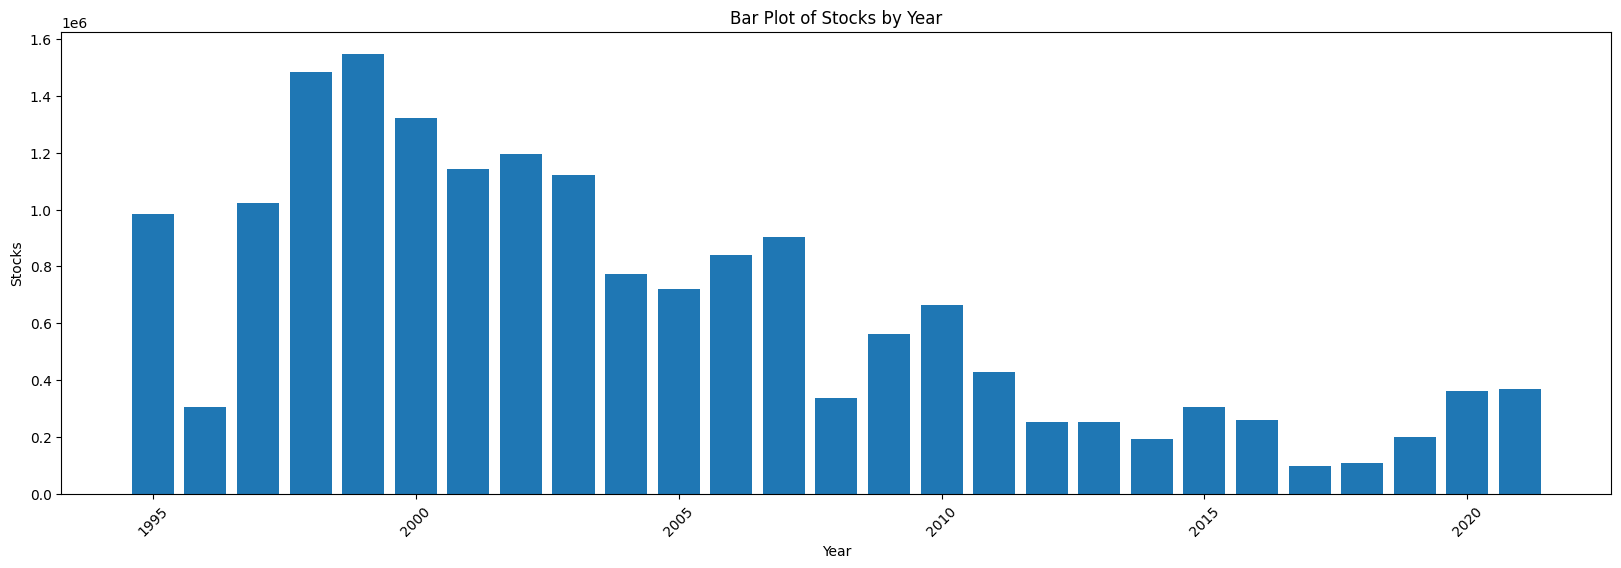

In [76]:
plt.figure(figsize=(20, 6))
plt.bar(az['year'], az['stocks'])
plt.xticks(rotation=45)
plt.title('Bar Plot of Stocks by Year')
plt.xlabel('Year')
plt.ylabel('Stocks')
plt.show()

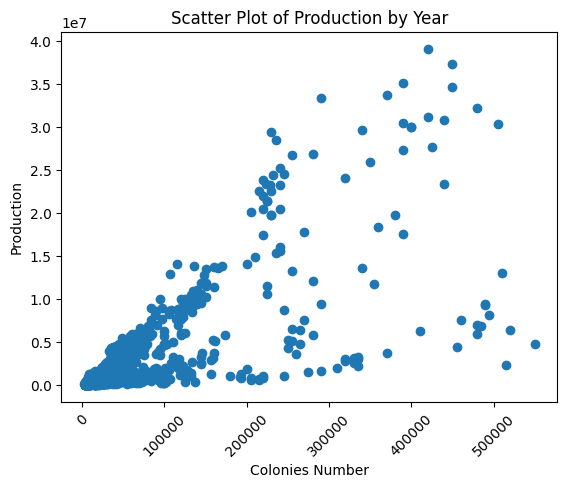

In [82]:
# plt.figure(figsize=(20, 6))
plt.scatter(df['colonies_number'], df['production'])
plt.xticks(rotation=45)
plt.title('Scatter Plot of Production by Year')
plt.xlabel('Colonies Number')
plt.ylabel('Production')
plt.show()

In [ ]:
year_prod = df.groupby('year')['production'].sum()

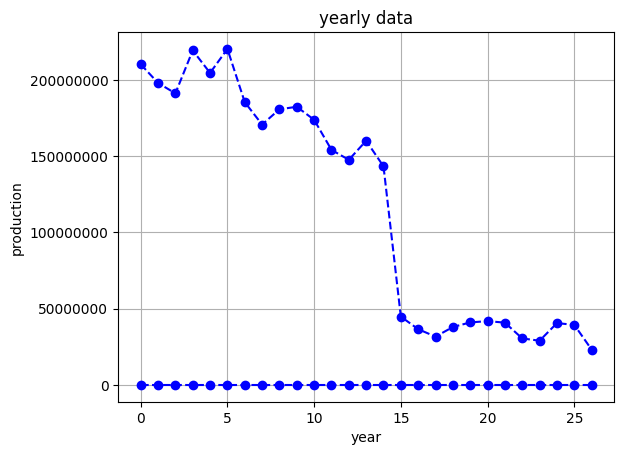

In [7]:
plt.plot(year_prod, marker='o', linestyle='--', color='b')
plt.title("yearly data")
plt.xlabel("year")
plt.ylabel("production")
plt.ticklabel_format(style='plain')
plt.grid(True)
plt.show()

In [8]:
pivot = pd.pivot_table(df, values='production', index='year', columns='state', aggfunc='sum')

In [12]:
pivot

state,Alabama,Arizona,Arkansas,California,Colorado,Florida,Georgia,Hawaii,Idaho,Illinois,...,SouthDakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,WestVirginia,Wisconsin,Wyoming
year,,,,,,,,,,,,,,,,,,,,,
1995,928000.0,4108000.0,3000000.0,39060000.0,2700000.0,19780000.0,4340000.0,1032000.0,6000000.0,814000.0,...,20400000.0,212000.0,8904000.0,1056000.0,335000.0,405000.0,3540000.0,533000.0,5767000.0,1368000.0
1996,1024000.0,1920000.0,3360000.0,27300000.0,2220000.0,25200000.0,5100000.0,1240000.0,4950000.0,814000.0,...,23280000.0,320000.0,6806000.0,1564000.0,332000.0,350000.0,3306000.0,590000.0,5382000.0,2920000.0
1997,924000.0,2560000.0,3800000.0,30000000.0,1925000.0,16080000.0,3450000.0,1314000.0,7680000.0,483000.0,...,15600000.0,372000.0,9964000.0,1664000.0,315000.0,424000.0,2808000.0,560000.0,4740000.0,2356000.0
1998,1136000.0,3300000.0,3445000.0,37350000.0,1944000.0,22540000.0,4200000.0,944000.0,6000000.0,639000.0,...,21375000.0,448000.0,7007000.0,1740000.0,384000.0,296000.0,2958000.0,330000.0,8099000.0,2760000.0
1999,1156000.0,3224000.0,4628000.0,30300000.0,2052000.0,23256000.0,3315000.0,640000.0,5760000.0,594000.0,...,23296000.0,408000.0,8748000.0,1170000.0,396000.0,245000.0,2600000.0,234000.0,6000000.0,2664000.0
2000,1248000.0,2360000.0,5115000.0,30800000.0,1740000.0,24360000.0,3135000.0,784000.0,4700000.0,488000.0,...,28435000.0,549000.0,8295000.0,984000.0,413000.0,294000.0,2808000.0,378000.0,7560000.0,3627000.0
2001,1022000.0,2537000.0,5655000.0,27625000.0,1430000.0,22000000.0,3135000.0,696000.0,4600000.0,456000.0,...,15275000.0,531000.0,7663000.0,874000.0,567000.0,468000.0,2184000.0,455000.0,5427000.0,2926000.0
2002,1032000.0,2394000.0,4840000.0,23320000.0,1440000.0,20460000.0,2600000.0,952000.0,5700000.0,720000.0,...,11475000.0,488000.0,7638000.0,1298000.0,623000.0,266000.0,2244000.0,459000.0,6650000.0,2394000.0
2003,1066000.0,2880000.0,3000000.0,32160000.0,2064000.0,14910000.0,3380000.0,791000.0,4600000.0,420000.0,...,14000000.0,280000.0,9380000.0,1311000.0,581000.0,222000.0,3248000.0,376000.0,5698000.0,3159000.0


In [10]:
check_states = pivot[['Alabama', 'Arizona', 'Florida','Texas']]

In [11]:
check_states

state,Alabama,Arizona,Florida,Texas
year,,,,
1995,928000.0,4108000.0,19780000.0,8904000.0
1996,1024000.0,1920000.0,25200000.0,6806000.0
1997,924000.0,2560000.0,16080000.0,9964000.0
1998,1136000.0,3300000.0,22540000.0,7007000.0
1999,1156000.0,3224000.0,23256000.0,8748000.0
2000,1248000.0,2360000.0,24360000.0,8295000.0
2001,1022000.0,2537000.0,22000000.0,7663000.0
2002,1032000.0,2394000.0,20460000.0,7638000.0
2003,1066000.0,2880000.0,14910000.0,9380000.0


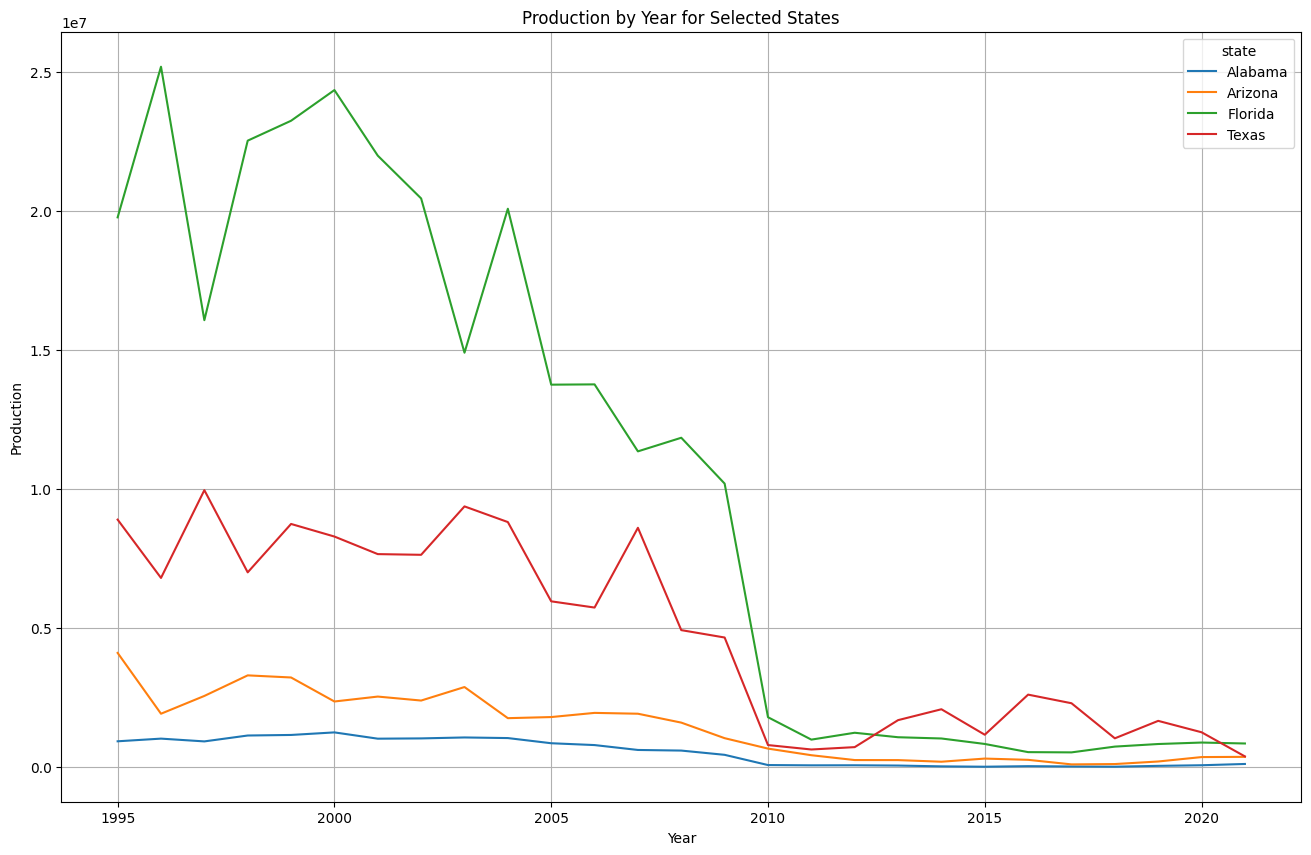

In [13]:
check_states.plot(figsize=(16, 10))
plt.title("Production by Year for Selected States")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

In [14]:
top_states = check_states.reset_index()


In [15]:
pivot_px = top_states.melt(id_vars='year', var_name='state', value_name='production')
pivot_px

,year,state,production
0,1995,Alabama,928000.0
1,1996,Alabama,1024000.0
2,1997,Alabama,924000.0
3,1998,Alabama,1136000.0
4,1999,Alabama,1156000.0
...,...,...,...
103,2017,Texas,2297000.0
104,2018,Texas,1035000.0
105,2019,Texas,1663000.0
106,2020,Texas,1253000.0
